In [1]:
import os, sys, joblib, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from pathlib import Path
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              recall_score, confusion_matrix)

try:
    _nb = globals().get('__vsc_ipynb_file__')
    if _nb:
        os.chdir(os.path.dirname(os.path.dirname(_nb)))
except Exception:
    pass

%load_ext autoreload
%autoreload 2
import config
%matplotlib inline

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.color': '#e0e0e0',
    'grid.linestyle': '--',
    'grid.alpha': 0.7,
    'font.size': 10,
})
print("CWD:", os.getcwd())



[*] SUCCESS: TensorFlow is utilizing the GPU -> /physical_device:GPU:0

CWD: /vol/bitbucket/gk225/POC_DDM/gk_code/main


In [2]:
sys.path.insert(0, 'utils')
sys.path.insert(0, 'utils/model_training')
from model_utils import build_well_stratified_random_split, build_well_stratified_nfold_splits
from sklearn.preprocessing import LabelEncoder

def reconstruct_well_splits(y_full, well_ids_full, mask=None, n_splits=1, random_state=0):
    """Replays evaluate_outlier_filters' own mask -> rare-class-drop -> well-stratified-split
    procedure (utils/model_training/model_utils.py:863-916) exactly, so the returned test-set
    well_ids line up with the cached y_trues_/y_preds_AC_* arrays. mask=None means the
    outlier_filter=None case (no rows removed pre-split). n_splits=1 uses the same
    max(10%, n_wells) test_size floor evaluate_outlier_filters uses for its single-split
    case; n_splits>1 returns that many well-stratified CV folds.
    Returns a list of (y_values_fold, well_ids_fold) pairs, one per fold, in the same
    order as evaluate_outlier_filters' own `splits` list."""
    if mask is None:
        mask = np.ones(len(y_full), dtype=bool)
    y_m, w_m = y_full[mask], well_ids_full[mask]

    unique_classes, class_counts = np.unique(y_m, return_counts=True)
    rare = unique_classes[class_counts < 2]
    valid = ~np.isin(y_m, rare)
    y_v, w_v = y_m[valid], w_m[valid]

    if n_splits == 1:
        n_wells = len(np.unique(w_v))
        test_size = max(len(y_v) * 0.10, n_wells) / len(y_v)
        splits = list(build_well_stratified_random_split(
            y_v, w_v, test_size=test_size, random_state=random_state).values())
    else:
        actual_splits = min(n_splits, len(np.unique(w_v)))
        splits = list(build_well_stratified_nfold_splits(
            y_v, w_v, n_splits=actual_splits, random_state=random_state).values())

    return [(y_v[test_idx], w_v[test_idx]) for _, test_idx in splits]

def remap_well_splits(well_ids_full, y_full, mask, global_splits):
    """Mirrors _remap_global_splits (utils/model_training/model_utils.py:710) plus the
    rare-class-drop step inside evaluate_outlier_filters, for the cv_splits-supplied path
    used by 04_cross_dataset_training.py's kfold/lofo modes -- where the split is computed
    ONCE on the full (unmasked) pool and then masked/remapped per outlier filter, rather
    than split fresh per filter like reconstruct_well_splits above.
    global_splits: dict or list of (train_idx, test_idx) pairs in full-pool index space.
    Returns a dict/list (matching global_splits' own container type) of
    (y_values_fold, well_ids_fold) pairs."""
    kept_global = np.where(mask)[0]
    y_m, w_m = y_full[mask], well_ids_full[mask]
    unique_classes, class_counts = np.unique(y_m, return_counts=True)
    rare = unique_classes[class_counts < 2]
    valid = ~np.isin(y_m, rare)
    kept_global = kept_global[valid]
    y_v, w_v = y_m[valid], w_m[valid]
    pos_lookup = {g: i for i, g in enumerate(kept_global)}

    def _remap_one(test_idx):
        local_test = np.array([pos_lookup[g] for g in test_idx if g in pos_lookup], dtype=int)
        return y_v[local_test], w_v[local_test]

    if isinstance(global_splits, dict):
        return {k: _remap_one(test_idx) for k, (_, test_idx) in global_splits.items()}
    return [_remap_one(test_idx) for _, test_idx in global_splits]

def well_level_accuracy(y_trues_flat, preds_flat, well_ids_test):
    """Majority-votes each well's pixel predictions into one verdict; accuracy over wells.
    The true label per well should be unanimous (one well = one label) -- a mismatch
    there signals a split-reconstruction bug, not real label noise."""
    wells = np.unique(well_ids_test)
    n_true_mismatch = 0
    correct = 0
    for w in wells:
        m = well_ids_test == w
        true_vals = pd.Series(y_trues_flat[m])
        if true_vals.nunique() > 1:
            n_true_mismatch += 1
        true_label = true_vals.mode()[0]
        pred_label = pd.Series(preds_flat[m]).mode()[0]
        correct += int(true_label == pred_label)
    if n_true_mismatch:
        print(f"  [!] {n_true_mismatch} well(s) had a non-unanimous true label -- "
              f"split reconstruction likely mismatched training.")
    return correct / len(wells), len(wells)

def verified_well_ids(y_true_cached, folds, context=""):
    """folds: list of (y_values_fold, well_ids_fold) pairs (from reconstruct_well_splits /
    remap_well_splits), covering the same rows as y_true_cached once concatenated in fold
    order. Returns the concatenated well_ids only if the concatenated y-values match
    y_true_cached exactly (length AND values) -- otherwise warns and returns None, so a
    reconstruction bug never silently produces a wrong well_accuracy number."""
    if not folds:
        return None
    y_check = np.concatenate([y for y, _ in folds])
    well_ids = np.concatenate([w for _, w in folds])
    if len(y_check) != len(y_true_cached) or not np.array_equal(y_check, y_true_cached):
        print(f"  [!] well-id reconstruction mismatch ({context}) -- skipping well_accuracy.")
        return None
    return well_ids

def verified_well_folds(cached_y_folds, folds, context=""):
    """Per-fold version of verified_well_ids -- for compute_fold_accuracy_stats, which needs
    one well_ids array per fold (not pooled) to compute a mean/std across folds. Returns a
    list of well_ids arrays (same fold order as cached_y_folds) only if every fold's
    y-values match exactly; otherwise warns and returns None."""
    if folds is None or len(folds) != len(cached_y_folds):
        print(f"  [!] well-id reconstruction mismatch ({context}: fold count) -- skipping well_accuracy.")
        return None
    out = []
    for (y_v, w_v), yt in zip(folds, cached_y_folds):
        if len(y_v) != len(yt) or not np.array_equal(y_v, yt):
            print(f"  [!] well-id reconstruction mismatch ({context}) -- skipping well_accuracy.")
            return None
        out.append(w_v)
    return out


In [3]:
FAMILIES = [
            'cnn_gru_dual', 
            'cnn_gru_dual_attn_recon', 
            ]
# SC_LEVELS = [0, 1, 2, 3]
SC_LEVELS = [0]

MODEL_KEY = {
    (fam, 0): fam for fam in FAMILIES
}

MODELS = [MODEL_KEY[(fam, sc)] for sc in SC_LEVELS for fam in FAMILIES]
MODEL_TO_FAMILY = {MODEL_KEY[(fam, sc)]: fam for sc in SC_LEVELS for fam in FAMILIES}

# ── Paths ─────────────────────────────────────────────────────────────────────

EXP_FOLDER = config.FINAL_EXP_FOLDER

TARGET_FOLDERS = config.CROSS_DATASET_GROUPS['final_6_new']

def short_name(folder):
    m = re.search(r'DDM_0(\d)', folder)
    return f'Chip 0{m.group(1)}' if m else folder.split('_U_', 1)[1]

DATASET_NAMES = [short_name(f) for f in TARGET_FOLDERS]

# ── Labels ────────────────────────────────────────────────────────────────────
# Standard model naming, shared across every section of this notebook (RQ2, RQ3.1, RQ3.2)
# and mirrored verbatim in 0_LOFO_INSPECTION.ipynb -- the single source of truth for how a
# model key is displayed on any chart.
FAMILY_LABELS = {
    'cnn_gru_dual': 'CNN-BiGRU',
    'cnn_gru_dual_dann': 'CNN-BiGRU\n+ DANN',
    'cnn_gru_dual_supcon3': 'CNN-BiGRU\n+ Contrastive Loss (SC3)',
    'cnn_gru_dual_pc_recenter': 'CNN-BiGRU\n+ Latent Alignment',

    'cnn_gru_dual_attn_recon':   'CNN-BiGRU + Spatial Attn',
    'cnn_gru_dual_attn_recon_aug': 'CNN-BiGRU + Spatial Attn\n+ Temporal Aug',
    'cnn_gru_dual_attn_recon_dann': 'CNN-BiGRU + Spatial Attn\n+ DANN',
    'cnn_gru_dual_attn_recon_supcon3': 'CNN-BiGRU + Spatial Attn\n+ Contrastive Loss (SC3)',
    'cnn_gru_dual_attn_recon_pc_recenter': 'CNN-BiGRU + Spatial Attn\n+ Latent Alignment',

    'cnn_gru_dual_cosine_recon': 'CNN-BiGRU + Cosine Recon',
    'ccgd_arch_poc_st': 'CCGD-ST',

    'knn': 'kNN',
    'cnn_gru_dual_attn_recon_dann_pc_recenter': 'CNN-BiGRU + Spatial Attn\n+ DANN + Latent Alignment',
    'cnn_gru_dual_attn_recon_supcon3_pc_recenter': 'CNN-BiGRU + Spatial Attn\n+ Contrastive Loss (SC3) + Latent Alignment',
    'cnn_gru_dual_attn_recon_aug_pc_recenter': 'CNN-BiGRU + Spatial Attn\n+ Temporal Aug + Latent Alignment',
    'cnn_gru_dual_attn_recon_mtl': 'CNN-BiGRU + Spatial Attn\n+ MTL',
    'cnn_gru_dual_attn_recon_mtl_pc_recenter': 'CNN-BiGRU + Spatial Attn\n+ MTL + Latent Alignment',
    'cnn_gru_dual_attn_recon_coral': 'CNN-BiGRU + Spatial Attn\n+ CORAL',
    'cnn_gru_dual_attn_recon_coral_pc_recenter': 'CNN-BiGRU + Spatial Attn\n+ CORAL + Latent Alignment',
}

# ── Colors ────────────────────────────────────────────────────────────────────
# dataviz-skill validated categorical palette, assigned in a `models`-list's order --
# shared by every grouped-bar-by-model chart in this notebook (RQ2 and RQ3.1 alike).
PALETTE = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100',
           '#e87ba4', '#008300', '#4a3aa7', '#e34948']

print(f"{len(MODELS)} models defined.")
print("  " + "\n  ".join(MODELS))


2 models defined.
  cnn_gru_dual
  cnn_gru_dual_attn_recon


In [4]:
TARGET_FOLDERS

['D20260827_E00_C00_F4500KHz_U_DDM_01_final_final',
 'D20260827_E00_C00_F4500KHz_U_DDM_02_final_final',
 'D20260827_E00_C00_F4500KHz_U_DDM_03_final_final',
 'D20260827_E00_C00_F4500KHz_U_DDM_04_final_final',
 'D20260825_E00_C00_F4500KHz_U_DDM_05_01',
 'D20260825_E00_C00_F4500KHz_U_DDM_06_02']

In [5]:
def compute_metrics(perf, model_key, well_ids=None):
    """Return dict with accuracy/f1/auc/sensitivity/specificity, or None if missing.
    well_ids (optional): array aligned 1:1 with concatenate(perf['y_trues_']) -- adds
    well_accuracy/n_wells (majority-vote-per-well accuracy) alongside the pixel-level
    metrics above. Pass an already length/value-verified array (see verified_well_ids)."""
    pred_k = f'y_preds_AC_{model_key}_'
    prob_k = f'y_probs_AC_{model_key}_'
    if pred_k not in perf:
        return None

    y_true  = np.concatenate(perf['y_trues_'])
    y_pred  = np.concatenate(perf[pred_k])
    y_probs = np.concatenate(perf[prob_k]) if prob_k in perf else None
    n_cls   = len(np.unique(y_true))

    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    sens = recall_score(y_true, y_pred, average='macro', zero_division=0)

    if y_probs is not None and n_cls > 1:
        try:
            auc = roc_auc_score(y_true, y_probs, multi_class='ovr', average='macro')
        except Exception:
            auc = np.nan
    else:
        auc = np.nan

    # Specificity = TN/(TN+FP) per class, macro-averaged
    cm = confusion_matrix(y_true, y_pred)
    specs = []
    for i in range(n_cls):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - cm[i, :].sum() - fp
        specs.append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)

    out = {'accuracy': acc, 'f1': f1, 'auc': auc,
           'sensitivity': sens, 'specificity': float(np.mean(specs))}

    if well_ids is not None:
        well_acc, n_wells = well_level_accuracy(y_true, y_pred, well_ids)
        out['well_accuracy'] = well_acc
        out['n_wells'] = n_wells

    return out


In [6]:
def macro_f1_sens_spec(y_true, y_pred):
    """F1/sensitivity (recall) macro-averaged, plus specificity (TN/(TN+FP) per class,
    macro-averaged) -- the exact computation compute_metrics uses on a single pooled
    split, factored out so compute_fold_accuracy_stats/load_cv_accuracy can call it once
    per fold instead (giving a real mean/std across folds rather than one pooled value)."""
    n_cls = len(np.unique(y_true))
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    sens = recall_score(y_true, y_pred, average='macro', zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    specs = []
    for i in range(n_cls):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - cm[i, :].sum() - fp
        specs.append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)
    return f1, sens, float(np.mean(specs))


# RQ2: PER-FOLD OUTLIER-FILTER ABLATION (Ablation 6)

Reads `ablations/ablation6_chip_outlier_model_ablation_performances.joblib` per chip --
a separate 5-fold CV run (`ablation6_chip_outlier_model_ablation.py`, `ori_curve_sg_p4_norm`)
comparing 2 models (baseline, no outlier filter), distinct from RQ2's single-split `classification_performances.joblib` above.

In [7]:
ABL6_MODELS = ['cnn_gru_dual', 'cnn_gru_dual_attn_recon']
ABL6_CURVE_TYPE = 'ori_curve_sg_p4_norm'
ABL6_FILTERS = [None]  # f_sngl_g13.sh's ablation6 run only trains the baseline (no filter)

print(f"{len(ABL6_MODELS)} models x {len(ABL6_FILTERS)} filters defined.")


2 models x 1 filters defined.


In [8]:
def compute_fold_accuracy_stats(perf, model_key, well_ids_folds=None):
    """Mean/std accuracy ACROSS folds (not pooled) -- matches ablation6_chip_outlier_model_ablation.py's
    own '86.85% ± 0.49%' log line exactly (utils/model_training/model_utils.py:2476-2486):
    one accuracy_score() per fold, then np.mean/np.std (ddof=0) across those fold-level numbers.
    F1/sensitivity/specificity get the same per-fold-then-mean/std treatment (via
    macro_f1_sens_spec), unlike compute_metrics' pooled versions of those three.
    well_ids_folds (optional): list of well_ids arrays, one per fold, same order/length as
    perf['y_trues_'] -- adds the well-level equivalent (well_accuracy_mean/std)."""
    pred_k = f'y_preds_AC_{model_key}_'
    if pred_k not in perf:
        return None
    fold_accs = [accuracy_score(yt, yp) for yt, yp in zip(perf['y_trues_'], perf[pred_k])]
    out = {'accuracy_mean': np.mean(fold_accs) * 100, 'accuracy_std': np.std(fold_accs) * 100}

    fold_f1s, fold_senss, fold_specs = [], [], []
    for yt, yp in zip(perf['y_trues_'], perf[pred_k]):
        f1, sens, spec = macro_f1_sens_spec(yt, yp)
        fold_f1s.append(f1); fold_senss.append(sens); fold_specs.append(spec)
    out['f1_mean'] = np.mean(fold_f1s) * 100;             out['f1_std'] = np.std(fold_f1s) * 100
    out['sensitivity_mean'] = np.mean(fold_senss) * 100;  out['sensitivity_std'] = np.std(fold_senss) * 100
    out['specificity_mean'] = np.mean(fold_specs) * 100;  out['specificity_std'] = np.std(fold_specs) * 100

    if well_ids_folds is not None:
        fold_well_accs = []
        for yt, yp, w in zip(perf['y_trues_'], perf[pred_k], well_ids_folds):
            wa, _ = well_level_accuracy(yt, yp, w)
            fold_well_accs.append(wa)
        out['well_accuracy_mean'] = np.mean(fold_well_accs) * 100
        out['well_accuracy_std'] = np.std(fold_well_accs) * 100
    return out


_ABL6_ARRAYS_CACHE = {}

def _abl6_training_arrays(exp_path):
    """y_full/well_ids_full/features_df exactly as ablation6_chip_outlier_model_ablation.py's
    run_one() derives them for ABL6_CURVE_TYPE, cached per exp_path (training_data is large
    and every filter for a given folder needs the same arrays)."""
    if exp_path in _ABL6_ARRAYS_CACHE:
        return _ABL6_ARRAYS_CACHE[exp_path]
    training_data = joblib.load(exp_path / config.TRAINING_DATA_PATH)
    dataset_name = list(training_data["dataset_name"])
    kinetic_features = training_data["kinetic_features"]
    Y_well = training_data["Y_well"]

    keep = [i for i, n in enumerate(dataset_name)
            if not n.startswith("avg_") and not n.startswith("original_fitted_stretched")]
    dataset_name = [dataset_name[i] for i in keep]
    kinetic_features = [kinetic_features[i] for i in keep]

    metadata_df = pd.DataFrame(training_data["metadata"])
    well_ids_full = (metadata_df["well_id"].values if "well_id" in metadata_df.columns
                      else np.array(Y_well).copy())

    label_mappings = config.get_label_mappings(exp_path)
    if exp_path.name in label_mappings:
        mapping = label_mappings[exp_path.name]
        Y_well = [mapping.get(w, w) for w in Y_well]
    encoder = LabelEncoder()
    y_full = encoder.fit_transform(Y_well)

    target_name = config.CURVE_TYPE_ALIASES.get(ABL6_CURVE_TYPE, ABL6_CURVE_TYPE)
    result = ((y_full, well_ids_full, kinetic_features[dataset_name.index(target_name)], encoder.classes_)
              if target_name in dataset_name else (None, None, None, None))
    _ABL6_ARRAYS_CACHE[exp_path] = result
    return result


def abl6_well_folds(exp_path, filt):
    y_full, well_ids_full, features_df, _ = _abl6_training_arrays(exp_path)
    if y_full is None:
        return None
    if filt is None:
        mask = np.ones(len(y_full), dtype=bool)
    elif filt not in features_df.columns:
        return None
    else:
        mask = (features_df[filt] == 1).fillna(False).values
    return reconstruct_well_splits(y_full, well_ids_full, mask=mask, n_splits=5)


def load_ablation6_all():
    rows = []
    for folder in TARGET_FOLDERS:
        dataset = short_name(folder)
        exp_path = Path(EXP_FOLDER) / folder
        path = exp_path / 'ablations' / 'ablation6_chip_outlier_model_ablation_performances.joblib'
        if not path.exists():
            print(f'[WARN] missing {path}')
            continue
        data = joblib.load(path)
        for filt in ABL6_FILTERS:
            perf = data.get(filt)
            if perf is None:
                continue
            well_folds = abl6_well_folds(exp_path, filt)
            for model in ABL6_MODELS:
                m = compute_metrics(perf, model)
                if m is None:
                    continue
                # Prefer well_ids_test_ (see load_all's comment above) over replaying the split.
                saved_well_ids_folds = perf.get('well_ids_test_')
                if saved_well_ids_folds is not None:
                    well_ids_folds = saved_well_ids_folds
                elif well_folds is not None:
                    well_ids_folds = verified_well_folds(perf['y_trues_'], well_folds,
                                                         context=f'{folder}/{filt}/{model}')
                else:
                    well_ids_folds = None
                stats = compute_fold_accuracy_stats(perf, model, well_ids_folds=well_ids_folds)
                rows.append(dict(dataset=dataset, outlier_filter=filt, model=model, **stats, **m))
    return pd.DataFrame(rows)

abl6_df = load_ablation6_all()
print(f"Loaded {len(abl6_df)} rows  |  "
      f"{abl6_df.dataset.nunique()} datasets  "
      f"{abl6_df.outlier_filter.nunique(dropna=False)} filters  "
      f"{abl6_df.model.nunique()} models")
abl6_df.head(8)


Loaded 12 rows  |  6 datasets  1 filters  2 models


,dataset,outlier_filter,model,accuracy_mean,accuracy_std,f1_mean,f1_std,sensitivity_mean,sensitivity_std,specificity_mean,specificity_std,well_accuracy_mean,well_accuracy_std,accuracy,f1,auc,sensitivity,specificity
0,Chip 01,None,cnn_gru_dual,82.998668,0.638526,77.714455,0.800007,77.550192,0.875064,96.630526,0.129338,100.000000,0.000000,0.829986,0.777173,0.968775,0.775504,0.966305
1,Chip 01,None,cnn_gru_dual_attn_recon,99.090419,0.354587,98.965879,0.408616,99.033958,0.514894,99.820410,0.073449,100.000000,0.000000,0.990904,0.989678,0.999793,0.990338,0.998204
2,Chip 02,None,cnn_gru_dual,87.967283,0.437577,84.917133,0.568043,84.642370,0.579360,97.492023,0.089534,100.000000,0.000000,0.879673,0.849167,0.982772,0.846424,0.974920
3,Chip 02,None,cnn_gru_dual_attn_recon,99.729519,0.317514,99.610999,0.480482,99.644644,0.456544,99.949237,0.058868,100.000000,0.000000,0.997295,0.996104,0.999971,0.996447,0.999492
4,Chip 03,None,cnn_gru_dual,69.249174,0.745902,67.026422,0.893863,66.740136,1.029452,93.546048,0.179422,100.000000,0.000000,0.692491,0.670623,0.939247,0.667395,0.935460
5,Chip 03,None,cnn_gru_dual_attn_recon,93.971674,1.135527,93.141730,1.566127,93.193279,1.707532,98.786761,0.229813,100.000000,0.000000,0.939716,0.931643,0.995473,0.931924,0.987867
6,Chip 04,None,cnn_gru_dual,68.889563,0.823232,73.121233,0.790032,73.106955,1.159813,93.045583,0.247726,91.111111,4.444444,0.688896,0.731598,0.929535,0.731064,0.930456
7,Chip 04,None,cnn_gru_dual_attn_recon,97.821602,0.600514,98.149854,0.660702,97.998181,0.923939,99.496207,0.149460,100.000000,0.000000,0.978216,0.981543,0.999005,0.979988,0.994962


In [9]:
def plot_accuracy_by_model_abl6(df, models, filt=None, value_col='accuracy_mean', std_col='accuracy_std',
                                value_label=None, figsize=(6, 4)):
    """Grouped bar chart: x=dataset, one sub-bar per model (order = `models`) -- same layout as
    plot_accuracy_by_model, but sourced from abl6_df's 5-fold mean/std columns and restricted to
    one outlier_filter (default None/baseline) instead of one (prep, curve_type). Error bars =
    std across the 5 CV folds; pass value_col='well_accuracy_mean', std_col='well_accuracy_std'
    for majority-vote well-level accuracy instead of pixel-level."""
    filt_mask = df.outlier_filter.isna() if filt is None else (df.outlier_filter == filt)
    sub = df[filt_mask]
    datasets = DATASET_NAMES
    n_models = len(models)
    bar_w = 0.8 / n_models
    x = np.arange(len(datasets))
    ylabel = value_label or f'{value_col.replace("_mean", "").replace("_", " ").title()} (%)'

    fig, ax = plt.subplots(figsize=figsize)
    for mi, model in enumerate(models):
        ys, errs = [], []
        for ds in datasets:
            r = sub[(sub.dataset == ds) & (sub.model == model)]
            if r.empty:
                ys.append(np.nan); errs.append(np.nan)
            else:
                ys.append(r[value_col].iloc[0]); errs.append(r[std_col].iloc[0])
        ys, errs = np.array(ys), np.array(errs)

        offset = (mi - (n_models - 1) / 2) * bar_w
        ax.bar(x + offset, np.nan_to_num(ys, nan=0), yerr=np.nan_to_num(errs, nan=0),
               width=bar_w, color=PALETTE[mi % len(PALETTE)],
               label=FAMILY_LABELS.get(model, model),
               edgecolor='white', linewidth=0.8,
               capsize=3, error_kw=dict(elinewidth=0.8, ecolor='#3a3a3a'))
        for xi, yi, ei in zip(x + offset, ys, errs):
            if not np.isnan(yi):
                ax.text(xi, yi + ei + 1.5, f'{yi:.2f}\n±{ei:.2f}', ha='center', va='bottom', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(datasets)
    ax.set_xlabel('Dataset')
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 108)
    ax.legend(fontsize=11, framealpha=0.9, loc='upper center',
              bbox_to_anchor=(0.5, -0.22), ncol=n_models)
    fig.tight_layout()
    plt.show()


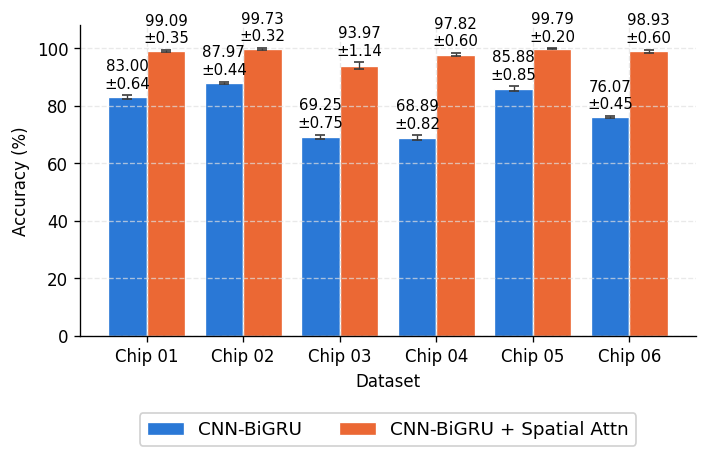

In [10]:
plot_accuracy_by_model_abl6(abl6_df, ['cnn_gru_dual', 'cnn_gru_dual_attn_recon']) #ABL6_MODELS)


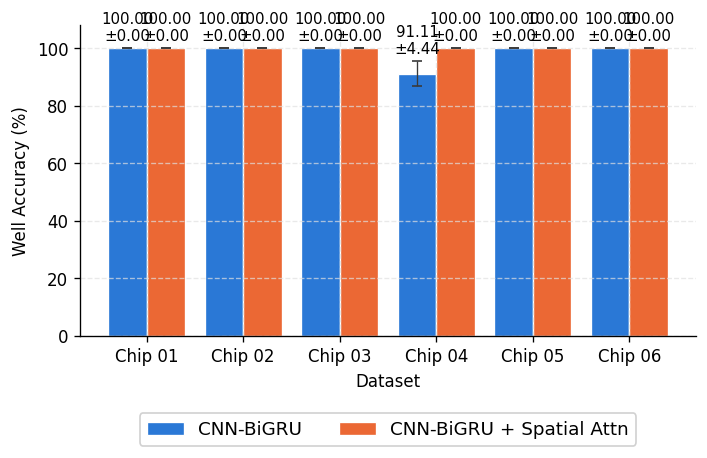

In [11]:
plot_accuracy_by_model_abl6(abl6_df, ['cnn_gru_dual', 'cnn_gru_dual_attn_recon'],
                             value_col='well_accuracy_mean', std_col='well_accuracy_std')

### LaTeX table -- Ablation6 baseline (no outlier filter), CNN-BiGRU vs. + Spatial Attn

Single table across all 4 datasets (rows), since only 2 models are compared: columns
are grouped by model (Accuracy, F1), each mean $\pm$ std across the 5 CV folds.


In [12]:
def build_abl6_latex_table(abl6_df, filt, models, model_labels, dataset_order,
                            caption, label, bold_model=None):
    filt_mask = abl6_df.outlier_filter.isna() if filt is None else (abl6_df.outlier_filter == filt)
    sub = abl6_df[filt_mask & abl6_df.model.isin(models)]

    metric_cols = [('accuracy_mean', 'accuracy_std'), ('f1_mean', 'f1_std'),
                   ('sensitivity_mean', 'sensitivity_std'), ('specificity_mean', 'specificity_std')]
    n_models = len(models)
    base_label = model_labels.get(models[0], models[0]).replace(chr(10), ' ')

    def row_label(m):
        full = model_labels.get(m, m).replace(chr(10), ' ')
        if m == models[0]:
            return full
        delta = full[len(base_label):].strip() if full.startswith(base_label) else full
        text = f'\\textbf{{{delta}}}' if m == bold_model else delta
        return f'\\quad {text}'

    lines = [
        '\\begin{table}[!htbp]',
        '    \\centering',
        f'    \\caption{{{caption}}}',
        f'    \\label{{{label}}}',
        '    \\small',
        '    \\begin{tabular}{@{}ll cccc@{}}',
        '    \\toprule',
        '    \\textbf{Dataset} & \\textbf{Model} & \\textbf{Accuracy} & \\textbf{F1} '
        '& \\textbf{Macro Sens.} & \\textbf{Macro Spec.} \\\\',
        '    \\midrule',
    ]
    for di, ds in enumerate(dataset_order):
        row = sub[sub.dataset == ds]
        lines.append(f'    \\multirow{{{n_models}}}{{*}}{{{ds}}}')
        for m in models:
            r = row[row.model == m]
            cells = []
            for mean_col, std_col in metric_cols:
                if r.empty:
                    cells.append('--')
                    continue
                v = f"{r[mean_col].iloc[0]:.2f} $\\pm$ {r[std_col].iloc[0]:.2f}"
                if m == bold_model:
                    v = f'\\textbf{{{v}}}'
                cells.append(v)
            lines.append(f'        & {row_label(m)} & {" & ".join(cells)} \\\\')
        if di != len(dataset_order) - 1:
            lines.append('    \\addlinespace')
    lines += ['    \\bottomrule', '    \\end{tabular}', '\\end{table}']
    return '\n'.join(lines)


abl6_latex = build_abl6_latex_table(
    abl6_df, filt=None,
    models=['cnn_gru_dual', 'cnn_gru_dual_attn_recon'], model_labels=FAMILY_LABELS,
    dataset_order=DATASET_NAMES, bold_model='cnn_gru_dual_attn_recon',
    caption=('Intra-chip evaluation across five-fold cross-validation. Each chip is '
             'trained and evaluated independently. Results are reported as mean '
             '$\\pm$ standard deviation across folds, and all values are percentages. '
             'Bold marks the best result on each chip.'),
    label='tab:abl6_baseline_acc_f1',
)
print(abl6_latex)


\begin{table}[!htbp]
    \centering
    \caption{Intra-chip evaluation across five-fold cross-validation. Each chip is trained and evaluated independently. Results are reported as mean $\pm$ standard deviation across folds, and all values are percentages. Bold marks the best result on each chip.}
    \label{tab:abl6_baseline_acc_f1}
    \small
    \begin{tabular}{@{}ll cccc@{}}
    \toprule
    \textbf{Dataset} & \textbf{Model} & \textbf{Accuracy} & \textbf{F1} & \textbf{Macro Sens.} & \textbf{Macro Spec.} \\
    \midrule
    \multirow{2}{*}{Chip 01}
        & CNN-BiGRU & 83.00 $\pm$ 0.64 & 77.71 $\pm$ 0.80 & 77.55 $\pm$ 0.88 & 96.63 $\pm$ 0.13 \\
        & \quad \textbf{+ Spatial Attn} & \textbf{99.09 $\pm$ 0.35} & \textbf{98.97 $\pm$ 0.41} & \textbf{99.03 $\pm$ 0.51} & \textbf{99.82 $\pm$ 0.07} \\
    \addlinespace
    \multirow{2}{*}{Chip 02}
        & CNN-BiGRU & 87.97 $\pm$ 0.44 & 84.92 $\pm$ 0.57 & 84.64 $\pm$ 0.58 & 97.49 $\pm$ 0.09 \\
        & \quad \textbf{+ Spatial Attn} & \

### LaTeX table -- Ablation6 per-class Sensitivity/Specificity (appendix, landscape)

In [13]:
def compute_per_class_sens_spec(perf, model_key, n_classes):
    pred_k = f'y_preds_AC_{model_key}_'
    if pred_k not in perf:
        return None
    fold_sens, fold_spec = [], []
    for yt, yp in zip(perf['y_trues_'], perf[pred_k]):
        cm = confusion_matrix(yt, yp, labels=range(n_classes))
        sens_c, spec_c = [], []
        for i in range(n_classes):
            tp = cm[i, i]
            fn = cm[i, :].sum() - tp
            fp = cm[:, i].sum() - tp
            tn = cm.sum() - tp - fn - fp
            sens_c.append(tp / (tp + fn) if (tp + fn) > 0 else np.nan)
            spec_c.append(tn / (tn + fp) if (tn + fp) > 0 else np.nan)
        fold_sens.append(sens_c)
        fold_spec.append(spec_c)
    fold_sens = np.array(fold_sens, dtype=float)
    fold_spec = np.array(fold_spec, dtype=float)
    return {
        'sens_mean': np.nanmean(fold_sens, axis=0) * 100, 'sens_std': np.nanstd(fold_sens, axis=0) * 100,
        'spec_mean': np.nanmean(fold_spec, axis=0) * 100, 'spec_std': np.nanstd(fold_spec, axis=0) * 100,
    }


def load_ablation6_per_class():
    rows = []
    for folder in TARGET_FOLDERS:
        dataset = short_name(folder)
        exp_path = Path(EXP_FOLDER) / folder
        path = exp_path / 'ablations' / 'ablation6_chip_outlier_model_ablation_performances.joblib'
        if not path.exists():
            continue
        _, _, _, class_names = _abl6_training_arrays(exp_path)
        if class_names is None:
            continue
        data = joblib.load(path)
        perf = data.get(None)
        if perf is None:
            continue
        for model in ABL6_MODELS:
            stats = compute_per_class_sens_spec(perf, model, len(class_names))
            if stats is None:
                continue
            for ci, cname in enumerate(class_names):
                rows.append(dict(dataset=dataset, model=model, class_name=cname,
                                 sens_mean=stats['sens_mean'][ci], sens_std=stats['sens_std'][ci],
                                 spec_mean=stats['spec_mean'][ci], spec_std=stats['spec_std'][ci]))
    return pd.DataFrame(rows)

abl6_per_class_df = load_ablation6_per_class()
print(f"Loaded {len(abl6_per_class_df)} rows  |  {abl6_per_class_df.dataset.nunique()} datasets  "
      f"{abl6_per_class_df['class_name'].nunique()} distinct classes  {abl6_per_class_df.model.nunique()} models")
abl6_per_class_df.head(8)


def build_abl6_per_class_latex_table(df, models, model_labels, dataset_order, caption, label):
    model_header = ' & '.join(
        f'\\multicolumn{{2}}{{c}}{{\\textbf{{{model_labels.get(m, m).replace(chr(10), " ")}}}}}'
        for m in models)
    model_cmid = ' '.join(f'\\cmidrule(lr){{{3 + 2*i}-{4 + 2*i}}}' for i in range(len(models)))
    metric_row = ' & '.join('\\textbf{Sens.} & \\textbf{Spec.}' for _ in models)

    lines = [
        '\\begin{landscape}',
        '\\begin{table}[!htbp]',
        '    \\centering',
        f'    \\caption{{{caption}}}',
        f'    \\label{{{label}}}',
        '    \\small',
        '    \\begin{tabular}{@{}ll' + 'cc' * len(models) + '@{}}',
        '    \\toprule',
        f'     & & {model_header} \\\\',
        f'    {model_cmid}',
        f'    \\textbf{{Dataset}} & \\textbf{{Class}} & {metric_row} \\\\',
        '    \\midrule',
    ]
    for di, ds in enumerate(dataset_order):
        sub_ds = df[df.dataset == ds]
        classes = sorted(sub_ds['class_name'].unique())
        if not classes:
            continue
        lines.append(f'    \\multirow{{{len(classes)}}}{{*}}{{{ds}}}')
        for cname in classes:
            per_model = {}
            for m in models:
                r = sub_ds[(sub_ds.model == m) & (sub_ds.class_name == cname)]
                per_model[m] = None if r.empty else (
                    r['sens_mean'].iloc[0], r['sens_std'].iloc[0],
                    r['spec_mean'].iloc[0], r['spec_std'].iloc[0])
            sens_vals = {m: v[0] for m, v in per_model.items() if v is not None}
            spec_vals = {m: v[2] for m, v in per_model.items() if v is not None}
            best_sens = max(sens_vals, key=sens_vals.get) if sens_vals else None
            best_spec = max(spec_vals, key=spec_vals.get) if spec_vals else None

            cells = []
            for m in models:
                v = per_model[m]
                if v is None:
                    cells += ['--', '--']
                    continue
                sens_mean, sens_std, spec_mean, spec_std = v
                sens_str = f"{sens_mean:.2f} $\\pm$ {sens_std:.2f}"
                spec_str = f"{spec_mean:.2f} $\\pm$ {spec_std:.2f}"
                if m == best_sens:
                    sens_str = f'\\textbf{{{sens_str}}}'
                if m == best_spec:
                    spec_str = f'\\textbf{{{spec_str}}}'
                cells.append(sens_str)
                cells.append(spec_str)
            lines.append(f'        & {cname} & {" & ".join(cells)} \\\\')
        if di != len(dataset_order) - 1:
            lines.append('    \\addlinespace')
    lines += ['    \\bottomrule', '    \\end{tabular}', '\\end{table}', '\\end{landscape}']
    return '\n'.join(lines)


abl6_per_class_latex = build_abl6_per_class_latex_table(
    abl6_per_class_df, models=['cnn_gru_dual', 'cnn_gru_dual_attn_recon'], model_labels=FAMILY_LABELS,
    dataset_order=DATASET_NAMES,
    caption=('Per-class sensitivity and specificity across five-fold cross-validation, '
             'per chip. Results are mean $\\pm$ standard deviation across folds, and all '
             'values are percentages.'),
    label='tab:abl6_per_class_sens_spec',
)
print(abl6_per_class_latex)


Loaded 72 rows  |  6 datasets  6 distinct classes  2 models


\begin{landscape}
\begin{table}[!htbp]
    \centering
    \caption{Per-class sensitivity and specificity across five-fold cross-validation, per chip. Results are mean $\pm$ standard deviation across folds, and all values are percentages.}
    \label{tab:abl6_per_class_sens_spec}
    \small
    \begin{tabular}{@{}llcccc@{}}
    \toprule
     & & \multicolumn{2}{c}{\textbf{CNN-BiGRU}} & \multicolumn{2}{c}{\textbf{CNN-BiGRU + Spatial Attn}} \\
    \cmidrule(lr){3-4} \cmidrule(lr){5-6}
    \textbf{Dataset} & \textbf{Class} & \textbf{Sens.} & \textbf{Spec.} & \textbf{Sens.} & \textbf{Spec.} \\
    \midrule
    \multirow{6}{*}{Chip 01}
        & Cov & 82.52 $\pm$ 1.62 & 97.32 $\pm$ 0.46 & \textbf{100.00 $\pm$ 0.00} & \textbf{100.00 $\pm$ 0.00} \\
        & Hadv & 82.50 $\pm$ 2.61 & 94.71 $\pm$ 0.79 & \textbf{97.47 $\pm$ 1.46} & \textbf{99.54 $\pm$ 0.51} \\
        & IAV & 98.01 $\pm$ 0.28 & 98.18 $\pm$ 0.20 & \textbf{100.00 $\pm$ 0.00} & \textbf{100.00 $\pm$ 0.00} \\
        & IBV & 50.91 $\